# 1. Load and Understand the Data

In this section, I load the two source datasets and review their basic structure. The patient census dataset shows which patients were present in each unit on each nightly census date. The bed pricing dataset shows the number of budgeted beds assigned to each unit and the daily funding value of an occupied budgeted bed. The purpose of this step is to confirm that the correct files were loaded and understand the size, columns, and basic content of each dataset before starting the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt
from sklearn.linear_model import LinearRegression


In [2]:
patient_data = pd.read_excel(
    "FSHN MRC – Patient Flow Census Data.xlsx",
    sheet_name="Bed Census"
)

bed_data = pd.read_excel(
    "Unit Bed Pricing and Allotment.xlsx",
    sheet_name="Unit and Bed Pricing"
)

In [3]:
patient_data.head()

,Health Card Number,Unique Patient Identifier,Event Type,Effective Date,Patient Type,Bed Asset Tag,Room Name,Department/Unit,Site
0,9700000003,SYN0000003,Census,2023-12-01 23:39:00,Adult Medical,N1D-B01,N1D-01A,North 1D,Magdelene RC
1,9700000002,SYN0000002,Census,2023-12-01 23:39:00,Geriatric,N1D-B03,N1D-02A,North 1D,Magdelene RC
2,9700000006,SYN0000006,Census,2023-12-01 23:39:00,Adult Medical,N1D-B04,N1D-02B,North 1D,Magdelene RC
3,9700000005,SYN0000005,Census,2023-12-01 23:39:00,Rehabilitation,N1D-B05,N1D-03A,North 1D,Magdelene RC
4,9700000004,SYN0000004,Census,2023-12-01 23:39:00,Rehabilitation,N1D-B06,N1D-03B,North 1D,Magdelene RC


In [4]:
bed_data

,Department/Unit,Budgeted Beds,Revenue Per Filled Bed
0,South 3D,10,5125
1,South 4D,5,9249
2,South 6C,10,3268
3,North 2D,17,7850
4,North 1D,10,3210
5,West 4A,15,1250


In [5]:
print("Patient data shape:", patient_data.shape)
print("Bed data shape:", bed_data.shape)

Patient data shape: (44947, 9)
Bed data shape: (6, 3)


# 2. Data Quality Validation

Before doing the analysis, I first checked the data to make sure it was reliable. I looked for missing values, duplicate records, missing census dates, and any mismatch between the patient census data and the bed-allocation data. The goal of this step was to make sure that the patient counts, occupancy calculations, forecasts, and financial analysis were based on clean and consistent data

In [6]:
# 2.1 Missing values

print("Missing values in patient data:")
print(patient_data.isnull().sum())

print("\nMissing values in bed data:")
print(bed_data.isnull().sum())

Missing values in patient data:
Health Card Number           0
Unique Patient Identifier    0
Event Type                   0
Effective Date               0
Patient Type                 0
Bed Asset Tag                0
Room Name                    0
Department/Unit              0
Site                         0
dtype: int64

Missing values in bed data:
Department/Unit           0
Budgeted Beds             0
Revenue Per Filled Bed    0
dtype: int64


In [7]:
# 2.2 Check duplicate rows

print("Duplicate rows in patient data:", patient_data.duplicated().sum())
print("Duplicate rows in bed data:", bed_data.duplicated().sum())

Duplicate rows in patient data: 0
Duplicate rows in bed data: 0


In [8]:
# 2.3 Data types

print("Patient data types:")
print(patient_data.dtypes)

print("\nBed data types:")
print(bed_data.dtypes)

Patient data types:
Health Card Number                    int64
Unique Patient Identifier               str
Event Type                              str
Effective Date               datetime64[us]
Patient Type                            str
Bed Asset Tag                           str
Room Name                               str
Department/Unit                         str
Site                                    str
dtype: object

Bed data types:
Department/Unit             str
Budgeted Beds             int64
Revenue Per Filled Bed    int64
dtype: object


In [9]:
# 2.4 Census date continuity

patient_data["Effective Date"] = pd.to_datetime(patient_data["Effective Date"])
start_date = patient_data["Effective Date"].dt.date.min()
end_date = patient_data["Effective Date"].dt.date.max()

expected_dates = pd.date_range(start=start_date, end=end_date)

actual_dates = pd.to_datetime(
    patient_data["Effective Date"].dt.date.unique()
)

missing_dates = expected_dates.difference(actual_dates)

print(start_date)
print(end_date)
print("Expected days:", len(expected_dates))
print("Missing dates:", len(missing_dates))

2023-12-01
2026-05-31
Expected days: 913
Missing dates: 0


In [10]:
# 2.6 Unit consistency between datasets

print("Units in patient data:")
print(sorted(patient_data["Department/Unit"].unique()))

print("Units in bed data:")
print(sorted(bed_data["Department/Unit"].unique()))

patient_units = set(patient_data["Department/Unit"].unique())
bed_units = set(bed_data["Department/Unit"].unique())

print("match?", patient_units == bed_units)

Units in patient data:
['North 1D', 'North 2D', 'South 3D', 'South 4D', 'South 6C', 'West 4A']
Units in bed data:
['North 1D', 'North 2D', 'South 3D', 'South 4D', 'South 6C', 'West 4A']
match? True


In [11]:
# 2.7 Check that patients and beds are not counted twice on the same census date

patient_data["Date"] = patient_data["Effective Date"].dt.date

patient_date_duplicates = patient_data.duplicated(
    subset=["Unique Patient Identifier", "Date"]
).sum()

bed_date_duplicates = patient_data.duplicated(
    subset=["Bed Asset Tag", "Date"]
).sum()

print("Duplicate patient-date:", patient_date_duplicates)
print("Duplicate bed-date:", bed_date_duplicates)

Duplicate patient-date: 0
Duplicate bed-date: 0


# 3. Build the Daily Census Table

The original census data contains one row for each patient recorded during the nightly census. For the capacity analysis, I converted the patient-level data into a daily unit-level table by counting how many patients were present in each unit on each census date. I then added the budgeted-bed and funding information for each unit so that patient demand could be compared directly with funded capacity

In [12]:
daily_census = (
    patient_data
    .groupby(["Date", "Department/Unit"])
    .size()
    .reset_index(name="Census")
)

In [13]:
daily_census = daily_census.merge(
    bed_data,
    on="Department/Unit",
    how="left"
)

In [14]:
daily_census.head()

,Date,Department/Unit,Census,Budgeted Beds,Revenue Per Filled Bed
0,2023-12-01,North 1D,5,10,3210
1,2023-12-01,North 2D,14,17,7850
2,2023-12-01,South 3D,6,10,5125
3,2023-12-01,South 4D,4,5,9249
4,2023-12-01,South 6C,11,10,3268


# 4. Daily Bed Utilization and Financial Impact

In this section, I compare the daily patient census with the number of budgeted beds in each unit. This allows me to measure whether a unit is operating above or below its funded capacity and to calculate the related financial impact

In [15]:
# Capacity gap

daily_census["Capacity Gap"] = (
    daily_census["Census"] - daily_census["Budgeted Beds"]
)

In [16]:
# Funded occupied beds

daily_census["Funded Occupied Beds"] = daily_census[
    ["Census", "Budgeted Beds"]
].min(axis=1)

In [17]:
# Unfunded patients

daily_census["Unfunded Patients"] = (
    daily_census["Capacity Gap"]
).clip(lower=0)

In [18]:
# Unfilled budgeted beds

daily_census["Unfilled Budgeted Beds"] = (
    -daily_census["Capacity Gap"]
).clip(lower=0)

In [19]:
# Budgeted-bed occupancy

daily_census["Occupancy %"] = (
    daily_census["Funded Occupied Beds"]
    / daily_census["Budgeted Beds"]
    * 100
).round(1)

In [20]:
# Funding earned

daily_census["Funding Earned"] = (
    daily_census["Funded Occupied Beds"]
    * daily_census["Revenue Per Filled Bed"]
)

In [21]:
# Empty-bed loss

daily_census["Empty Bed Loss"] = (
    daily_census["Unfilled Budgeted Beds"]
    * daily_census["Revenue Per Filled Bed"]
    / 2
)

In [22]:
# Net funding

daily_census["Net Funding"] = (
    daily_census["Funding Earned"]
    - daily_census["Empty Bed Loss"]
)

In [23]:
# Missed funding opportunity

daily_census["Missed Funding Opportunity"] = (
    daily_census["Unfunded Patients"]
    * daily_census["Revenue Per Filled Bed"]
)

In [24]:
# results

daily_census[
    [
        "Date",
        "Department/Unit",
        "Census",
        "Budgeted Beds",
        "Capacity Gap",
        "Funded Occupied Beds",
        "Unfunded Patients",
        "Unfilled Budgeted Beds",
        "Occupancy %",
        "Funding Earned",
        "Empty Bed Loss",
        "Net Funding",
        "Missed Funding Opportunity"
    ]
].head(12)

,Date,Department/Unit,Census,Budgeted Beds,Capacity Gap,Funded Occupied Beds,Unfunded Patients,Unfilled Budgeted Beds,Occupancy %,Funding Earned,Empty Bed Loss,Net Funding,Missed Funding Opportunity
0,2023-12-01,North 1D,5,10,-5,5,0,5,50.0,16050,8025.0,8025.0,0
1,2023-12-01,North 2D,14,17,-3,14,0,3,82.4,109900,11775.0,98125.0,0
2,2023-12-01,South 3D,6,10,-4,6,0,4,60.0,30750,10250.0,20500.0,0
3,2023-12-01,South 4D,4,5,-1,4,0,1,80.0,36996,4624.5,32371.5,0
4,2023-12-01,South 6C,11,10,1,10,1,0,100.0,32680,0.0,32680.0,3268
5,2023-12-01,West 4A,6,15,-9,6,0,9,40.0,7500,5625.0,1875.0,0
6,2023-12-02,North 1D,6,10,-4,6,0,4,60.0,19260,6420.0,12840.0,0
7,2023-12-02,North 2D,13,17,-4,13,0,4,76.5,102050,15700.0,86350.0,0
8,2023-12-02,South 3D,5,10,-5,5,0,5,50.0,25625,12812.5,12812.5,0
9,2023-12-02,South 4D,5,5,0,5,0,0,100.0,46245,0.0,46245.0,0


In [25]:
# Check South 3D

daily_census[
    daily_census["Department/Unit"] == "South 3D"
][
    [
        "Date",
        "Census",
        "Budgeted Beds",
        "Capacity Gap",
        "Unfunded Patients",
        "Unfilled Budgeted Beds",
        "Occupancy %",
        "Missed Funding Opportunity"
    ]
].tail(10)

,Date,Census,Budgeted Beds,Capacity Gap,Unfunded Patients,Unfilled Budgeted Beds,Occupancy %,Missed Funding Opportunity
5420,2026-05-22,22,10,12,12,0,100.0,61500
5426,2026-05-23,21,10,11,11,0,100.0,56375
5432,2026-05-24,18,10,8,8,0,100.0,41000
5438,2026-05-25,20,10,10,10,0,100.0,51250
5444,2026-05-26,21,10,11,11,0,100.0,56375
5450,2026-05-27,20,10,10,10,0,100.0,51250
5456,2026-05-28,20,10,10,10,0,100.0,51250
5462,2026-05-29,20,10,10,10,0,100.0,51250
5468,2026-05-30,21,10,11,11,0,100.0,56375
5474,2026-05-31,21,10,11,11,0,100.0,56375


In [26]:
# Check South 2D

daily_census[
    daily_census["Department/Unit"] == "North 2D"
][
    [
        "Date",
        "Census",
        "Budgeted Beds",
        "Capacity Gap",
        "Unfunded Patients",
        "Unfilled Budgeted Beds",
        "Occupancy %",
        "Missed Funding Opportunity"
    ]
].tail(10)

,Date,Census,Budgeted Beds,Capacity Gap,Unfunded Patients,Unfilled Budgeted Beds,Occupancy %,Missed Funding Opportunity
5419,2026-05-22,11,17,-6,0,6,64.7,0
5425,2026-05-23,11,17,-6,0,6,64.7,0
5431,2026-05-24,12,17,-5,0,5,70.6,0
5437,2026-05-25,11,17,-6,0,6,64.7,0
5443,2026-05-26,12,17,-5,0,5,70.6,0
5449,2026-05-27,11,17,-6,0,6,64.7,0
5455,2026-05-28,10,17,-7,0,7,58.8,0
5461,2026-05-29,11,17,-6,0,6,64.7,0
5467,2026-05-30,11,17,-6,0,6,64.7,0
5473,2026-05-31,13,17,-4,0,4,76.5,0


# 5. Historical Performance and Demand Trends

In this section, I review how patient demand and bed utilization have changed over time. I focus especially on the most recent six months because recent operating conditions are more relevant to the upcoming six-month forecast.
The goal is to understand whether South 3D's capacity problem is persistent, whether North 2D has spare capacity, and whether other units should also be considered in the bed-allocation decision

In [27]:
daily_census["Above Budget"] = daily_census["Unfunded Patients"] > 0
daily_census["Below Budget"] = daily_census["Unfilled Budgeted Beds"] > 0

In [28]:
daily_census["Date"] = pd.to_datetime(daily_census["Date"])

last_date = daily_census["Date"].max()

recent_start = (
    last_date
    - pd.DateOffset(months=6)
    + pd.Timedelta(days=1)
)

print("Recent period:", recent_start.date(), "to", last_date.date())

Recent period: 2025-12-01 to 2026-05-31


In [29]:
recent_data = daily_census[
    daily_census["Date"] >= recent_start
].copy()

print("Number of recent days:", recent_data["Date"].nunique())

Number of recent days: 182


In [30]:
recent_summary = (
    recent_data
    .groupby("Department/Unit")
    .agg(
        Budgeted_Beds=("Budgeted Beds", "first"),
        Average_Census=("Census", "mean"),
        Minimum_Census=("Census", "min"),
        Maximum_Census=("Census", "max"),
        Average_Occupancy=("Occupancy %", "mean"),
        Days_Above_Budget=("Above Budget", "sum"),
        Days_Below_Budget=("Below Budget", "sum"),
        Unfunded_Bed_Days=("Unfunded Patients", "sum"),
        Unfilled_Bed_Days=("Unfilled Budgeted Beds", "sum"),
        Missed_Funding=("Missed Funding Opportunity", "sum"),
        Empty_Bed_Loss=("Empty Bed Loss", "sum")
    )
    .reset_index()
)

recent_summary

,Department/Unit,Budgeted_Beds,Average_Census,Minimum_Census,Maximum_Census,Average_Occupancy,Days_Above_Budget,Days_Below_Budget,Unfunded_Bed_Days,Unfilled_Bed_Days,Missed_Funding,Empty_Bed_Loss
0,North 1D,10,6.351648,1,9,63.516484,0,182,0,664,0,1065720.0
1,North 2D,17,12.901099,10,15,75.904396,0,182,0,746,0,2928050.0
2,South 3D,10,17.192308,11,22,100.000000,182,0,1309,0,6708625,0.0
3,South 4D,5,4.384615,1,6,83.736264,36,89,36,148,332964,684426.0
4,South 6C,10,9.230769,4,11,90.054945,41,93,41,181,133988,295754.0
5,West 4A,15,8.093407,3,10,53.962088,0,182,0,1257,0,785625.0


In [31]:
# monthly average census trend

monthly_census = (
    daily_census
    .groupby([
        pd.Grouper(key="Date", freq="MS"),
        "Department/Unit"
    ])["Census"]
    .mean()
    .reset_index()
)

monthly_census.head()

,Date,Department/Unit,Census
0,2023-12-01,North 1D,6.741935
1,2023-12-01,North 2D,14.129032
2,2023-12-01,South 3D,5.419355
3,2023-12-01,South 4D,4.935484
4,2023-12-01,South 6C,9.806452


In [32]:
main_units_monthly = monthly_census[
    monthly_census["Department/Unit"].isin(
        ["South 3D", "North 2D"]
    )
]

main_units_monthly.tail(12)

,Date,Department/Unit,Census
145,2025-12-01,North 2D,13.870968
146,2025-12-01,South 3D,13.064516
151,2026-01-01,North 2D,13.419355
152,2026-01-01,South 3D,14.967742
157,2026-02-01,North 2D,13.142857
158,2026-02-01,South 3D,16.678571
163,2026-03-01,North 2D,12.709677
164,2026-03-01,South 3D,17.741935
169,2026-04-01,North 2D,12.233333
170,2026-04-01,South 3D,20.266667


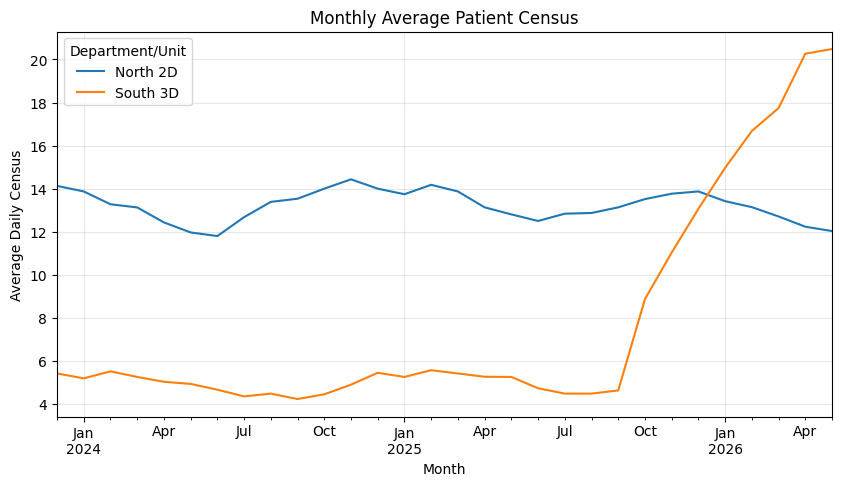

In [33]:
monthly_plot = main_units_monthly.pivot(
    index="Date",
    columns="Department/Unit",
    values="Census"
)

monthly_plot.plot(figsize=(10, 5))

plt.title("Monthly Average Patient Census")
plt.xlabel("Month")
plt.ylabel("Average Daily Census")
plt.grid(alpha=0.3)
plt.show()

In [34]:
monthly_unique_patients = (
    patient_data[
        patient_data["Department/Unit"].isin([
            "South 3D",
            "North 2D"
        ])
    ]
    .groupby([
        pd.Grouper(key="Effective Date", freq="MS"),
        "Department/Unit"
    ])["Unique Patient Identifier"]
    .nunique()
    .reset_index(name="Unique Patients")
)

monthly_unique_patients.head()

,Effective Date,Department/Unit,Unique Patients
0,2023-12-01,North 2D,50
1,2023-12-01,South 3D,31
2,2024-01-01,North 2D,51
3,2024-01-01,South 3D,23
4,2024-02-01,North 2D,58


In [35]:
unique_patient_pivot = (
    monthly_unique_patients
    .pivot(
        index="Effective Date",
        columns="Department/Unit",
        values="Unique Patients"
    )
)

unique_patient_pivot.tail(12)

Department/Unit,North 2D,South 3D
Effective Date,,
2025-06-01,47,22
2025-07-01,62,27
2025-08-01,49,28
2025-09-01,48,20
2025-10-01,53,40
2025-11-01,54,50
2025-12-01,49,53
2026-01-01,54,58
2026-02-01,47,43


<Axes: title={'center': 'Monthly Unique Patients: South 3D vs North 2D'}, xlabel='Effective Date'>

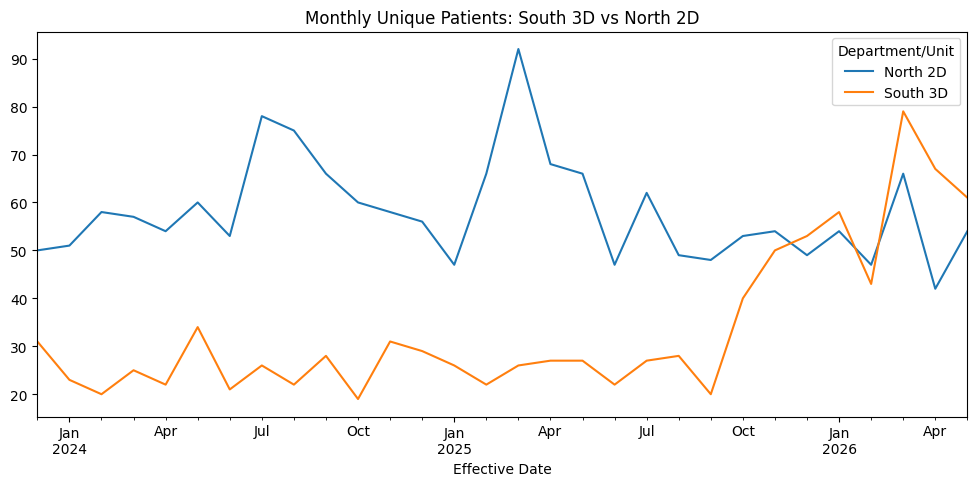

In [36]:
unique_patient_pivot.plot(
    figsize=(12, 5),
    title="Monthly Unique Patients: South 3D vs North 2D"
)

In [37]:
monthly_bed_days = (
    patient_data[
        patient_data["Department/Unit"].isin([
            "South 3D",
            "North 2D"
        ])
    ]
    .groupby([
        pd.Grouper(key="Effective Date", freq="MS"),
        "Department/Unit"
    ])
    .size()
    .reset_index(name="Patient Bed-Days"))

In [38]:
monthly_patient_flow = monthly_bed_days.merge(
    monthly_unique_patients,
    on=["Effective Date", "Department/Unit"]
)

In [39]:
monthly_patient_flow["Bed-Days per Unique Patient"] = (
    monthly_patient_flow["Patient Bed-Days"]
    / monthly_patient_flow["Unique Patients"]
)

In [40]:
bed_days_per_patient_pivot = (
    monthly_patient_flow
    .pivot(
        index="Effective Date",
        columns="Department/Unit",
        values="Bed-Days per Unique Patient"
    )
)
bed_days_per_patient_pivot.tail(12)

Department/Unit,North 2D,South 3D
Effective Date,,
2025-06-01,7.978723,6.454545
2025-07-01,6.419355,5.148148
2025-08-01,8.142857,4.964286
2025-09-01,8.208333,6.950000
2025-10-01,7.905660,6.875000
2025-11-01,7.648148,6.620000
2025-12-01,8.775510,7.641509
2026-01-01,7.703704,8.000000
2026-02-01,7.829787,10.860465


<Axes: title={'center': 'Monthly Bed-Days per Unique Patient: South 3D vs North 2D'}, xlabel='Effective Date'>

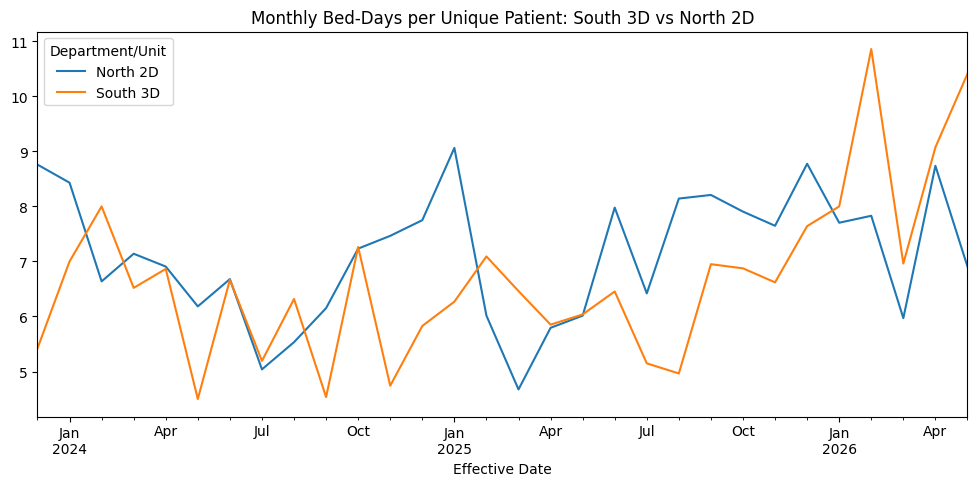

In [41]:
bed_days_per_patient_pivot.plot(
    figsize=(12, 5),
    title="Monthly Bed-Days per Unique Patient: South 3D vs North 2D"
)

# 6. Forecast Patient Census for the Next Six Months

The goal of this section is to estimate patient volumes for the next six months. South 3D and North 2D have different historical patterns, so I evaluate them separately. South 3D has experienced strong recent growth, while North 2D has been relatively stable. I compare simple forecasting methods using a 60-day historical holdout period. I evaluate the models using Mean Absolute Error (MAE) and bias, then select a model that provides both reasonable accuracy and a sensible six-month forecast

In [42]:
# South 3D

south_ts = (
    daily_census[
        daily_census["Department/Unit"] == "South 3D"
    ]
    .set_index("Date")["Census"]
    .sort_index()
)

south_ts.head()

Date
2023-12-01    6
2023-12-02    5
2023-12-03    6
2023-12-04    7
2023-12-05    7
Name: Census, dtype: int64

In [43]:
# North 2D

north_ts = (
    daily_census[
        daily_census["Department/Unit"] == "North 2D"
    ]
    .set_index("Date")["Census"]
    .sort_index()
)

north_ts.head()

Date
2023-12-01    14
2023-12-02    13
2023-12-03    13
2023-12-04    15
2023-12-05    15
Name: Census, dtype: int64

## 6.1 South 3D

In [44]:
# Create South 3D recent-period data

south_recent_ts = south_ts[
    south_ts.index >= "2025-10-01"
]

print("Recent South 3D period")
print("Start:", south_recent_ts.index.min())
print("End:", south_recent_ts.index.max())
print("Days:", len(south_recent_ts))

Recent South 3D period
Start: 2025-10-01 00:00:00
End: 2026-05-31 00:00:00
Days: 243


In [45]:
# Create a 60-day holdout

holdout_days = 60

south_train = south_recent_ts.iloc[:-holdout_days]
south_test = south_recent_ts.iloc[-holdout_days:]

print("Recent-regime training period:")
print(south_train.index.min(), "to", south_train.index.max())

print("\nTest period:")
print(south_test.index.min(), "to", south_test.index.max())

print("\nTraining days:", len(south_train))
print("Test days:", len(south_test))

Recent-regime training period:
2025-10-01 00:00:00 to 2026-04-01 00:00:00

Test period:
2026-04-02 00:00:00 to 2026-05-31 00:00:00

Training days: 183
Test days: 60


In [46]:
# full-history training

test_start = south_test.index.min()

south_full_train = south_ts[
    south_ts.index < test_start
]

print("Full-history training days:", len(south_full_train))

Full-history training days: 853


In [47]:
# Model 1 — Recent mean benchmark

recent_mean_value = south_train.tail(28).mean()

south_mean_forecast = pd.Series(
    recent_mean_value,
    index=south_test.index
)

mean_mae = (
    south_test - south_mean_forecast
).abs().mean()

mean_bias = (
    south_test - south_mean_forecast
).mean()

print("Recent Mean MAE:", round(mean_mae, 2))
print("Recent Mean Bias:", round(mean_bias, 2))

Recent Mean MAE: 2.8
Recent Mean Bias: 2.77


In [48]:
# Model 2 — Holt linear trend

holt_linear_model = Holt(
    south_train,
    damped_trend=False
).fit()

south_holt_linear_forecast = holt_linear_model.forecast(
    len(south_test)
)

holt_linear_mae = (
    south_test - south_holt_linear_forecast
).abs().mean()

holt_linear_bias = (
    south_test - south_holt_linear_forecast
).mean()

print("Recent-regime Holt Linear MAE:",
      round(holt_linear_mae, 2))

print("Recent-regime Holt Linear Bias:",
      round(holt_linear_bias, 2))

C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Recent-regime Holt Linear MAE: 2.68
Recent-regime Holt Linear Bias: 2.65


In [49]:
# Model 3: Holt damped trend

holt_damped_model = Holt(
    south_train,
    damped_trend=True
).fit()

south_holt_damped_forecast = holt_damped_model.forecast(
    len(south_test)
)

holt_damped_mae = (
    south_test - south_holt_damped_forecast
).abs().mean()

holt_damped_bias = (
    south_test - south_holt_damped_forecast
).mean()

print("Recent-regime Holt Damped MAE:",
      round(holt_damped_mae, 2))

print("Recent-regime Holt Damped Bias:",
      round(holt_damped_bias, 2))

Recent-regime Holt Damped MAE: 2.68
Recent-regime Holt Damped Bias: 2.65


C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [50]:
# Full-history Holt linear

full_holt_linear_model = Holt(
    south_full_train,
    damped_trend=False
).fit()

full_holt_linear_forecast = full_holt_linear_model.forecast(
    len(south_test)
)

full_holt_linear_mae = (
    south_test - full_holt_linear_forecast
).abs().mean()

full_holt_linear_bias = (
    south_test - full_holt_linear_forecast
).mean()

print("Full-history Holt Linear MAE:",
      round(full_holt_linear_mae, 2))

print("Full-history Holt Linear Bias:",
      round(full_holt_linear_bias, 2))

Full-history Holt Linear MAE: 2.0
Full-history Holt Linear Bias: 1.9


C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [51]:
# Full-history Holt damped

full_holt_damped_model = Holt(
    south_full_train,
    damped_trend=True
).fit()

full_holt_damped_forecast = full_holt_damped_model.forecast(
    len(south_test)
)

full_holt_damped_mae = (
    south_test - full_holt_damped_forecast
).abs().mean()

full_holt_damped_bias = (
    south_test - full_holt_damped_forecast
).mean()

print("Full-history Holt Damped MAE:",
      round(full_holt_damped_mae, 2))

print("Full-history Holt Damped Bias:",
      round(full_holt_damped_bias, 2))

C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Full-history Holt Damped MAE: 2.68
Full-history Holt Damped Bias: 2.65


In [52]:
# Compare South 3D models

south_model_comparison = pd.DataFrame({
    "Model": [
        "Recent Mean",
        "Recent Holt Linear",
        "Recent Holt Damped",
        "Full History Holt Linear",
        "Full History Holt Damped"
    ],
    "MAE": [
        mean_mae,
        holt_linear_mae,
        holt_damped_mae,
        full_holt_linear_mae,
        full_holt_damped_mae
    ],
    "Bias": [
        mean_bias,
        holt_linear_bias,
        holt_damped_bias,
        full_holt_linear_bias,
        full_holt_damped_bias
    ]
})

south_model_comparison.round(2)

,Model,MAE,Bias
0,Recent Mean,2.80,2.77
1,Recent Holt Linear,2.68,2.65
2,Recent Holt Damped,2.68,2.65
3,Full History Holt Linear,2.00,1.90
4,Full History Holt Damped,2.68,2.65


South 3D Model Selection:

I compared several forecasting approaches using the same 60-day holdout period. Holt Linear performed better on the short-term validation period. However, South 3D's sharp increase is relatively recent, and Holt Linear assumes that this upward trend continues throughout the full six-month forecast horizon. This produced a relatively aggressive long-term forecast. For planning purposes, I therefore selected **Holt Damped** as the primary forecast. It still captures the recent increase in South 3D demand, but gradually reduces the growth rate over time, providing a more conservative assumption for a six-month planning decision. The better-performing Holt Linear model is retained as a higher-growth sensitivity scenario to test whether the recommendation changes if South 3D's recent growth continues more strongly. This approach balances short-term model accuracy with uncertainty around the sustainability of the recent demand increase

In [53]:
 # Create future dates for South 3D

forecast_dates = pd.date_range(
    start="2026-06-01",
    end="2026-11-30",
    freq="D"
)

print("Forecast period:", forecast_dates.min(), "to", forecast_dates.max())
print("Forecast days:", len(forecast_dates))

Forecast period: 2026-06-01 00:00:00 to 2026-11-30 00:00:00
Forecast days: 183


In [54]:
south_final_model = Holt(
    south_ts,
    damped_trend=True
).fit()

C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [55]:
south_future = south_final_model.forecast(
    len(forecast_dates)
)

south_future.index = forecast_dates

In [56]:
south_future.head()

2026-06-01    20.779316
2026-06-02    20.779316
2026-06-03    20.779316
2026-06-04    20.779316
2026-06-05    20.779316
Freq: D, dtype: float64

In [57]:
south_monthly_forecast = (
    south_future
    .resample("MS")
    .mean()
    .round(1)
)

south_monthly_forecast

2026-06-01    20.8
2026-07-01    20.8
2026-08-01    20.8
2026-09-01    20.8
2026-10-01    20.8
2026-11-01    20.8
Freq: MS, dtype: float64

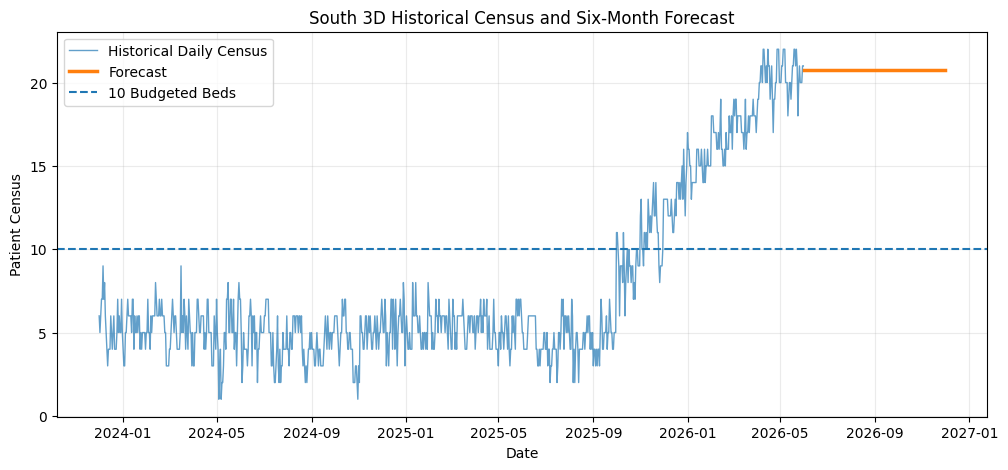

In [58]:
plt.figure(figsize=(12, 5))

plt.plot(
    south_ts.index,
    south_ts.values,
    label="Historical Daily Census",
    linewidth=1,
    alpha=0.7
)

plt.plot(
    south_future.index,
    south_future.values,
    label="Forecast",
    linewidth=2.5
)

plt.axhline(
    y=10,
    linestyle="--",
    linewidth=1.5,
    label="10 Budgeted Beds"
)

plt.title("South 3D Historical Census and Six-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Patient Census")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

### 6.2 North 2D 

In [59]:
north_train = north_ts.iloc[:-60]
north_test = north_ts.iloc[-60:]

print("Training days:", len(north_train))
print("Test days:", len(north_test))

Training days: 853
Test days: 60


In [60]:
north_mean_value = north_train.tail(28).mean()

north_mean_forecast = pd.Series(
    north_mean_value,
    index=north_test.index
)

north_mean_mae = (
    north_test - north_mean_forecast
).abs().mean()

north_mean_bias = (
    north_test - north_mean_forecast
).mean()

print("Recent Mean MAE:", round(north_mean_mae, 2))
print("Recent Mean Bias:", round(north_mean_bias, 2))

Recent Mean MAE: 1.0
Recent Mean Bias: -0.31


In [61]:
north_linear_model = Holt(
    north_train,
    damped_trend=False
).fit()

north_linear_forecast = north_linear_model.forecast(
    len(north_test)
)

north_linear_mae = (
    north_test - north_linear_forecast
).abs().mean()

north_linear_bias = (
    north_test - north_linear_forecast
).mean()

print("Holt Linear MAE:", round(north_linear_mae, 2))
print("Holt Linear Bias:", round(north_linear_bias, 2))

Holt Linear MAE: 1.09
Holt Linear Bias: 0.8


C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [62]:
north_damped_model = Holt(
    north_train,
    damped_trend=True
).fit()

north_damped_forecast = north_damped_model.forecast(
    len(north_test)
)

north_damped_mae = (
    north_test - north_damped_forecast
).abs().mean()

north_damped_bias = (
    north_test - north_damped_forecast
).mean()

print("Holt Damped MAE:", round(north_damped_mae, 2))
print("Holt Damped Bias:", round(north_damped_bias, 2))

Holt Damped MAE: 0.94
Holt Damped Bias: -0.12


C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [63]:
north_model_comparison = pd.DataFrame({
    "Model": [
        "Recent Mean",
        "Holt Linear",
        "Holt Damped"
    ],
    "MAE": [
        north_mean_mae,
        north_linear_mae,
        north_damped_mae
    ],
    "Bias": [
        north_mean_bias,
        north_linear_bias,
        north_damped_bias
    ]
})

north_model_comparison.round(2)

,Model,MAE,Bias
0,Recent Mean,1.00,-0.31
1,Holt Linear,1.09,0.80
2,Holt Damped,0.94,-0.12


North 2D Model Selection:

North 2D showed a relatively stable historical census pattern.Among the three tested models, Holt damped produced the lowest MAE and the smallest forecasting bias on the 60-day holdout. Therefore, I selected Holt damped as the final forecasting model for North 2D

In [64]:
north_final_model = Holt(
    north_ts,
    damped_trend=True
).fit()

north_future = north_final_model.forecast(
    len(forecast_dates)
)

north_future.index = forecast_dates

C:\Users\sadeq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [65]:
north_monthly_forecast = (
    north_future
    .resample("MS")
    .mean()
    .round(1)
)

north_monthly_forecast

2026-06-01    11.8
2026-07-01    11.8
2026-08-01    11.8
2026-09-01    11.8
2026-10-01    11.8
2026-11-01    11.8
Freq: MS, dtype: float64

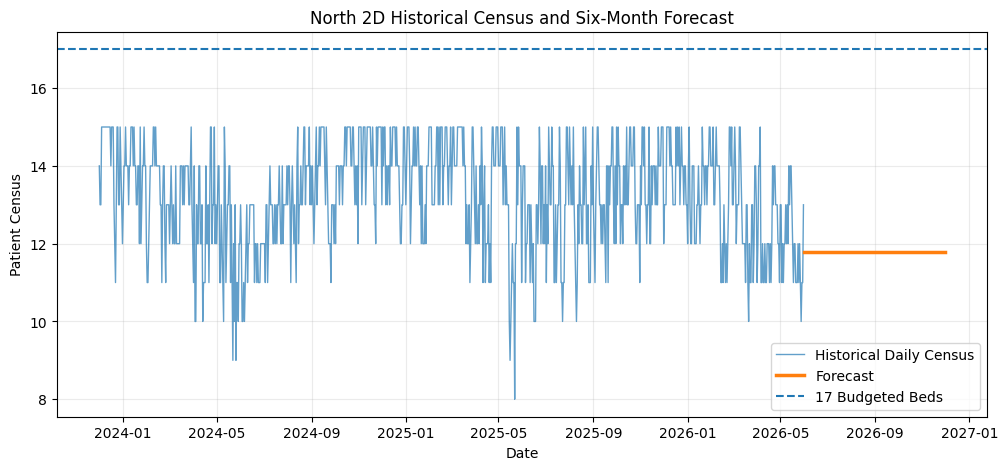

In [66]:
plt.figure(figsize=(12, 5))

plt.plot(
    north_ts.index,
    north_ts.values,
    label="Historical Daily Census",
    linewidth=1,
    alpha=0.7
)

plt.plot(
    north_future.index,
    north_future.values,
    label="Forecast",
    linewidth=2.5
)

plt.axhline(
    y=17,
    linestyle="--",
    linewidth=1.5,
    label="17 Budgeted Beds"
)

plt.title("North 2D Historical Census and Six-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Patient Census")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

# 7. No-Change Scenario

In this section, I estimate what would happen over the next six months if the current bed allocations remain unchanged. South 3D remains at 10 budgeted beds and North 2D remains at 17 budgeted beds.
Using the selected forecasts, I calculate expected occupancy, unfunded patient-bed days, unfilled budgeted-bed days, and the related financial impact.

In [67]:
future_data = pd.DataFrame({
    "Date": forecast_dates,
    "South 3D Census": south_future.values,
    "North 2D Census": north_future.values
})

In [68]:
south_beds = 10
north_beds = 17

south_rate = 5125
north_rate = 7850

In [69]:
# South capacity

future_data["South Funded"] = future_data[
    "South 3D Census"
].clip(upper=south_beds)

future_data["South Unfunded"] = (
    future_data["South 3D Census"] - south_beds
).clip(lower=0)

future_data["South Unfilled"] = (
    south_beds - future_data["South 3D Census"]
).clip(lower=0)

In [70]:
# North capacity

future_data["North Funded"] = future_data[
    "North 2D Census"
].clip(upper=north_beds)

future_data["North Unfunded"] = (
    future_data["North 2D Census"] - north_beds
).clip(lower=0)

future_data["North Unfilled"] = (
    north_beds - future_data["North 2D Census"]
).clip(lower=0)

In [71]:
# Occupancy %

future_data["South Occupancy %"] = (
    future_data["South Funded"] / south_beds * 100
)

future_data["North Occupancy %"] = (
    future_data["North Funded"] / north_beds * 100
)


In [72]:
# South Funding Earned, Empty Bed Loss, Missed Funding Opportunity

future_data["South Funding Earned"] = (
    future_data["South Funded"] * south_rate
)

future_data["South Empty Bed Loss"] = (
    future_data["South Unfilled"] * south_rate / 2
)

future_data["South Net Funding"] = (
    future_data["South Funding Earned"]
    - future_data["South Empty Bed Loss"]
)

future_data["South Missed Funding"] = (
    future_data["South Unfunded"] * south_rate
)

In [73]:
# North Funding Earned, Empty Bed Loss, Missed Funding Opportunity


future_data["North Funding Earned"] = (
    future_data["North Funded"] * north_rate
)

future_data["North Empty Bed Loss"] = (
    future_data["North Unfilled"] * north_rate / 2
)

future_data["North Net Funding"] = (
    future_data["North Funding Earned"]
    - future_data["North Empty Bed Loss"]
)

future_data["North Missed Funding"] = (
    future_data["North Unfunded"] * north_rate
)

In [74]:
no_change_summary = pd.DataFrame({
    "Unit": ["South 3D", "North 2D"],
    "Average Forecast Census": [
        future_data["South 3D Census"].mean(),
        future_data["North 2D Census"].mean()
    ],
    "Average Occupancy %": [
        future_data["South Occupancy %"].mean(),
        future_data["North Occupancy %"].mean()
    ],
    "Unfunded Bed-Days": [
        future_data["South Unfunded"].sum(),
        future_data["North Unfunded"].sum()
    ],
    "Unfilled Bed-Days": [
        future_data["South Unfilled"].sum(),
        future_data["North Unfilled"].sum()
    ],
    "Net Funding": [
        future_data["South Net Funding"].sum(),
        future_data["North Net Funding"].sum()
    ],
    "Missed Funding Opportunity": [
        future_data["South Missed Funding"].sum(),
        future_data["North Missed Funding"].sum()
    ]
})

no_change_summary.round(1)

,Unit,Average Forecast Census,Average Occupancy %,Unfunded Bed-Days,Unfilled Bed-Days,Net Funding,Missed Funding Opportunity
0,South 3D,20.8,100.0,1972.6,0.0,9378750.0,10109650.8
1,North 2D,11.8,69.3,0.0,954.2,13185108.5,0.0


# 8. Bed Reallocation Scenario Analysis

The goal of this section is to determine how many budgeted beds could be reallocated from North 2D to South 3D. I test a range of transfer scenarios using the six-month planning forecasts. For each scenario, I evaluate occupancy, unfunded patient-bed days, unfilled budgeted-bed days, and financial impact for both units. The objective is to improve South 3D's capacity position without creating excessive pressure or underfunding in North 2D.

In [75]:
south_scenario_forecast = south_future.copy()
north_scenario_forecast = north_future.copy()

In [76]:
scenario_results = []

for transfer in range(0, 11):

    south_beds_new = 10 + transfer
    north_beds_new = 17 - transfer

    south_funded = south_scenario_forecast.clip(
        upper=south_beds_new
    )

    south_unfunded = (
        south_scenario_forecast - south_beds_new
    ).clip(lower=0)

    south_unfilled = (
        south_beds_new - south_scenario_forecast
    ).clip(lower=0)

    north_funded = north_scenario_forecast.clip(
        upper=north_beds_new
    )

    north_unfunded = (
        north_scenario_forecast - north_beds_new
    ).clip(lower=0)

    north_unfilled = (
        north_beds_new - north_scenario_forecast
    ).clip(lower=0)

    south_occupancy = (
        south_funded / south_beds_new * 100
    ).mean()

    north_occupancy = (
        north_funded / north_beds_new * 100
    ).mean()

    south_missed_funding = (
        south_unfunded * south_rate
    ).sum()

    north_missed_funding = (
        north_unfunded * north_rate
    ).sum()

    south_empty_loss = (
        south_unfilled * south_rate / 2
    ).sum()

    north_empty_loss = (
        north_unfilled * north_rate / 2
    ).sum()

    scenario_results.append({
        "Beds Transferred": transfer,
        "South Beds": south_beds_new,
        "North Beds": north_beds_new,
        "South Occupancy %": south_occupancy,
        "North Occupancy %": north_occupancy,
        "South Unfunded Bed-Days": south_unfunded.sum(),
        "North Unfunded Bed-Days": north_unfunded.sum(),
        "South Missed Funding": south_missed_funding,
        "North Missed Funding": north_missed_funding,
        "South Empty Bed Loss": south_empty_loss,
        "North Empty Bed Loss": north_empty_loss
    })

In [77]:
scenario_table = pd.DataFrame(scenario_results)

scenario_table.round(1)

,Beds Transferred,South Beds,North Beds,South Occupancy %,North Occupancy %,South Unfunded Bed-Days,North Unfunded Bed-Days,South Missed Funding,North Missed Funding,South Empty Bed Loss,North Empty Bed Loss
0,0,10,17,100.0,69.3,1972.6,0.0,10109650.8,0.0,0.0,3745413.8
1,1,11,16,100.0,73.7,1789.6,0.0,9171775.8,0.0,0.0,3027138.8
2,2,12,15,100.0,78.6,1606.6,0.0,8233900.8,0.0,0.0,2308863.8
3,3,13,14,100.0,84.2,1423.6,0.0,7296025.8,0.0,0.0,1590588.8
4,4,14,13,100.0,90.7,1240.6,0.0,6358150.8,0.0,0.0,872313.8
5,5,15,12,100.0,98.2,1057.6,0.0,5420275.8,0.0,0.0,154038.8
6,6,16,11,100.0,100.0,874.6,143.8,4482400.8,1128472.3,0.0,0.0
7,7,17,10,100.0,100.0,691.6,326.8,3544525.8,2565022.3,0.0,0.0
8,8,18,9,100.0,100.0,508.6,509.8,2606650.8,4001572.3,0.0,0.0
9,9,19,8,100.0,100.0,325.6,692.8,1668775.8,5438122.3,0.0,0.0


In [78]:
tradeoff_table = scenario_table[
    scenario_table["Beds Transferred"].isin([3, 4, 5])
][[
    "Beds Transferred",
    "South Beds",
    "North Beds",
    "North Occupancy %",
    "South Unfunded Bed-Days",
    "North Unfunded Bed-Days",
    "South Missed Funding",
    "North Empty Bed Loss"
]]

tradeoff_table.round(1)

,Beds Transferred,South Beds,North Beds,North Occupancy %,South Unfunded Bed-Days,North Unfunded Bed-Days,South Missed Funding,North Empty Bed Loss
3,3,13,14,84.2,1423.6,0.0,7296025.8,1590588.8
4,4,14,13,90.7,1240.6,0.0,6358150.8,872313.8
5,5,15,12,98.2,1057.6,0.0,5420275.8,154038.8


In [80]:
north_sensitivity_results = []

for demand_increase in [0, 1, 2]:

    stressed_north = north_future + demand_increase
    north_beds_test = 13   # North after transferring 4 beds

    occupied = stressed_north.clip(upper=north_beds_test)

    unfunded = (
        stressed_north - north_beds_test
    ).clip(lower=0)

    occupancy = (
        occupied / north_beds_test * 100
    ).mean()

    north_sensitivity_results.append({
        "Demand Scenario": demand_increase,
        "Average Census": stressed_north.mean(),
        "Average Occupancy %": occupancy,
        "Unfunded Bed-Days": unfunded.sum()
    })

north_sensitivity = pd.DataFrame(north_sensitivity_results)

north_sensitivity["Demand Scenario"] = [
    "Base Forecast",
    "+1 Patient per Day",
    "+2 Patients per Day"
]

north_sensitivity.round(1)

,Demand Scenario,Average Census,Average Occupancy %,Unfunded Bed-Days
0,Base Forecast,11.8,90.7,0.0
1,+1 Patient per Day,12.8,98.4,0.0
2,+2 Patients per Day,13.8,100.0,143.8
